# Confusion Matrix

* Module Name: confusion.ipynb
* Description: generate confusion matrix

Copyright (C) 2025 J.Cincotta

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program. If not, see <https://www.gnu.org/licenses/>.


In [1]:
from pyarrow import timestamp
from welfareobs.detectron.detectron_configuration import get_configuration
from welfareobs.detectron.detectron_calls import image_tensor, predict
from welfareobs.detectron.welfareobs_dataset import WelfareObsDataset
from detectron2.config import instantiate
from detectron2.checkpoint import DetectionCheckpointer
from welfareobs.handlers.abstract_handler import AbstractHandler
from welfareobs.models.frame import Frame
from welfareobs.models.individual import Individual
from welfareobs.utils.config import Config
from welfareobs.utils.bgr_transform import BGRTransform 
from welfareobs.utils.padded_square_transform import PaddedSquareTransform
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch
import os
import itertools
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, brier_score_loss, roc_auc_score, accuracy_score
from sklearn.exceptions import ConvergenceWarning
import warnings
from tqdm import tqdm
import pandas as pd
from IPython.display import display, HTML
import random



In [2]:
"""
Notebook configuration parameters:
"""
config_name = "config/detection-wod-md-adamw.json" # used in the pipelines
# For running confusion matrix
batch_size = 32 # batch size (tuned for the GPU)
num_images = 16 * 43 # total number of images to load based on the training set of 700 divided by batch size 


In [3]:
"""
Load up the configuration
"""

cnf: Config = Config(config_name)
source_image_dimensions = cnf.as_int("input-dimensions")
reid_dimensions = cnf.as_int("reid-dimensions")
reid_model_root = cnf.as_string("reid-model-root")
reid_timm_backbone = cnf.as_string("reid-timm-backbone")
segmentation_checkpoint = cnf.as_string("segmentation-checkpoint")
print("Configuration set")

Configuration set


In [4]:
"""
Utility to provide GPU info
"""
def print_gpu_memory():
    print(f"Allocated memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Cached memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


In [5]:
"""
Clean up
"""
import gc

gc.collect()
torch.cuda.empty_cache()

print_gpu_memory()


Allocated memory: 0.00 MB
Cached memory: 0.00 MB


In [6]:
"""
Load the model
"""
print(f"Reading model {reid_model_root}.")
model = instantiate(
    get_configuration(
        reid_model_root,
        backbone=reid_timm_backbone,
        dimensions=reid_dimensions
    )
)
# then load it with the pretrained backbone
DetectionCheckpointer(model).load(segmentation_checkpoint)
model.eval()
model = model.to("cuda")
print_gpu_memory()

Reading model /project/data/results/wod-md-adamw.
Using device: cuda
Allocated memory: 1006.50 MB
Cached memory: 2514.00 MB


In [7]:
"""
Load the dataset for evaluation
"""


dataset=WelfareObsDataset(
    root="/project/data/wod_reid",
    annotations_file="coco_test.json",
    transform = T.Compose([
        PaddedSquareTransform(fill=0, padding_mode="constant"), #edge
        T.PILToTensor(), # Convert a PIL Image or ndarray to tensor and scale the values 0->255 to 0.0->1.0
        T.Resize(
            size=(source_image_dimensions,source_image_dimensions),
            interpolation=T.InterpolationMode.BILINEAR,
            max_size=None,
            antialias=True
        ),
        # note that we do NOT normalise the image because that is happening inside Detectron2
        BGRTransform()  # since our data source is RGB
        # T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]),
    img_load="bbox", # "bbox_mask",
    col_path="path",
    col_label="identity",
    load_label=True
)




In [8]:
"""
Dump image sample (only works for small values of num_images)
"""
# samples = 5
# fig, axs = plt.subplots(nrows=samples, ncols=1, figsize=(10, 10))
# for index, (item, ax) in enumerate(zip(itertools.islice(dataset, samples),axs)):
#     ax.imshow(np.array(item[0], copy=None, dtype=None).transpose(1, 2, 0)[ :, : ,[2, 1, 0]])  # 
#     ax.axis('off')


'\nDump image sample (only works for small values of num_images)\n'

In [9]:
def dump_instance(output):
    print(f"Available fields in the result: {','.join([o for o in output.get_fields().keys()])}")
    _classes = list(output.get("pred_classes").cpu().numpy())
    if len(_classes) > 0:
        _boxes = list(output.get("pred_boxes").to("cpu"))
        _masks = list(output.get("pred_masks").cpu().numpy())
        _scores = list(output.get("scores").cpu().numpy())
        print("Boxes:")
        for c, b, s in zip(_classes, _boxes, _scores):
            if c>0:
                print(f"Class: {c} Score: {s} = {b}")

def dump_crop(image, box, score, reid, known):
    print(f"Score: {score} - ReId: {reid}|{known} ")
    img = image
    src = image
    if box is not None:
        x1, y1, x2, y2 = box
        img = image[:,int(y1):int(y2), int(x1):int(x2)]
    img = (img.cpu().squeeze(0).permute(1,2,0).numpy())[ :, : ,:]
    src = (src.cpu().squeeze(0).permute(1,2,0).numpy())[ :, : ,:]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[1].imshow(src)
    plt.show()
    print("______________________________________________________")

In [10]:
# used in the next
raw_results = []

known_classes = []
known_batch = []
prediction_classes = []
missed_count = 0
subset = itertools.islice(dataset, num_images)
for i in tqdm(range(0, num_images, batch_size), mininterval=1, ncols=100):
    image_tensors = []
    torch.cuda.empty_cache()
    known_batch = []
    for item in itertools.islice(subset, batch_size):
        image_tensors.append(item[0])
        known_classes.append(dataset.labels_map[item[1]])
        known_batch.append(dataset.labels_map[item[1]])        
    if len(image_tensors) > 0:
        output = predict(image_tensors, model)
        for index, item in enumerate(output):
            # dump_instance(item)
            known = known_batch[index]
            item = item["instances"]
            step_result = 0
            if item.has("reid_embeddings"):
                # Since we have pre-cropped data from the testing dataset, and we know there may be more than one 
                # proposal for a single image, but it *should* resolve to a single identification. This is an
                # inherent problem in region proposal - so we consolidate the proposals to max 5 
                # (one for each individual, plus '-1' - an unknown reid which is returned from the reid head)
                
                _reids = list(item.get("reid_embeddings").cpu().numpy().flatten())
                _scores = list(item.get("scores").cpu().numpy()) # kept this in case we want to threshold
                _boxes = list(item.get("pred_boxes").to("cpu"))
               
                class_score = {}
                class_box = {}
                class_count = {}
                
                for r, s, b in zip(_reids, _scores, _boxes):
                    r = int(r)
                    class_score[r] = float(s + class_score.get(r,0))
                    class_count[r] = int(1 + class_count.get(r,0))
                    # expand all REIDs into a single REID proposal
                    x1, y1, x2, y2 = b.cpu().numpy()
                    xx1, yy1, xx2, yy2 = class_box.get(r,(x1, y1, x2, y2))
                    class_box[r] = (
                        xx1 if xx1 < x1 else x1,
                        yy1 if yy1 < y1 else y1,
                        xx2 if xx2 > x2 else x2,
                        yy2 if yy2 > y2 else y2
                    )

                # We need to identify a winning REID/BBOX proposal, as this is equivalent to the 
                # real-world usage scenario. We use a strategy of combining the probability 
                # scores of all the proposals for a REID into a single score and multiply that by the 
                # area of the combined proposal bounding box. 
                #
                # This approach weights larger, confident proposals.
                
                winning_score = 0.0
                winning_key = -1
                for key in class_score.keys():
                    x1, y1, x2, y2 = class_box[key]
                    val = float(class_score[key] * ((x2-x1)*(y2-y1)))
                    if (key > -1) and (val > winning_score):
                        winning_key = key
                        winning_score = val
                
                if winning_key > -1:
                    raw_results.append((
                        image_tensors[index], 
                        class_box[winning_key], 
                        winning_score, 
                        winning_key,
                        known))
                    prediction_classes.append(winning_key)
                else:
                    # We did get a reid head output but no valid prediction was made, this is a "null" prediction
                    raw_results.append((image_tensors[index], None, None, None, known))
                    prediction_classes.append(0)
            else:
                missed_count += 1
                # No RE-Id occurred in the Detectron pipeline, this means NO giraffe could be identified
                # even if we have detection proposals, so we track these as failures (missed count)
                # this is slightly different from the above failure - so we track these with a counter
                # a lot of these would indicate poor training data
                raw_results.append((image_tensors[index], None, None, None, known))
                prediction_classes.append(0)
    torch.cuda.empty_cache()



  0%|                                                                        | 0/22 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|███████████████████████████████████████████████████████████████| 22/22 [02:39<00:00,  7.27s/it]


Score: 2142974.25 - ReId: 2|4 


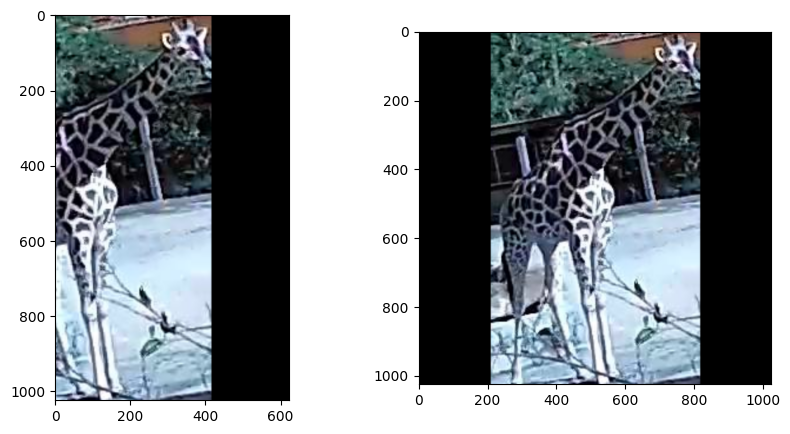

______________________________________________________
Score: 2119804.25 - ReId: 3|3 


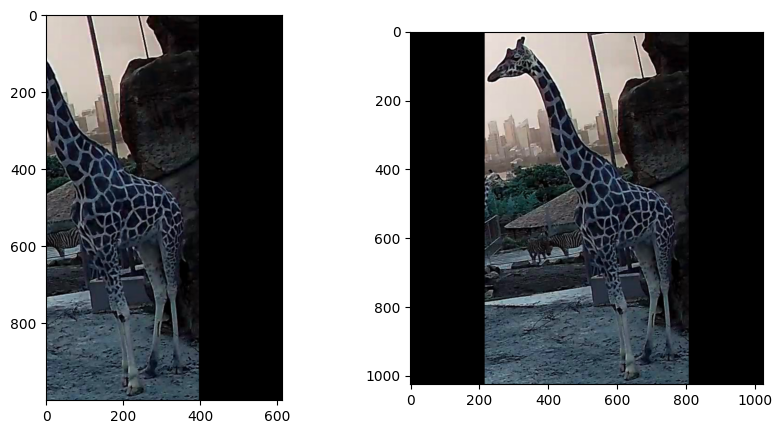

______________________________________________________
Score: 1532613.625 - ReId: 3|2 


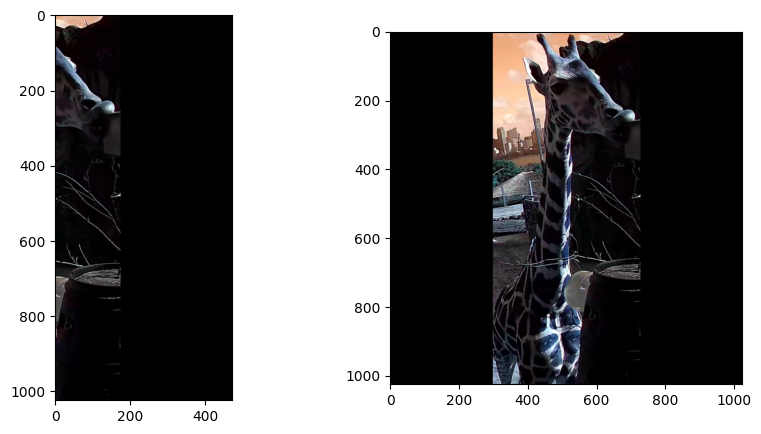

______________________________________________________
Score: 1904848.75 - ReId: 2|2 


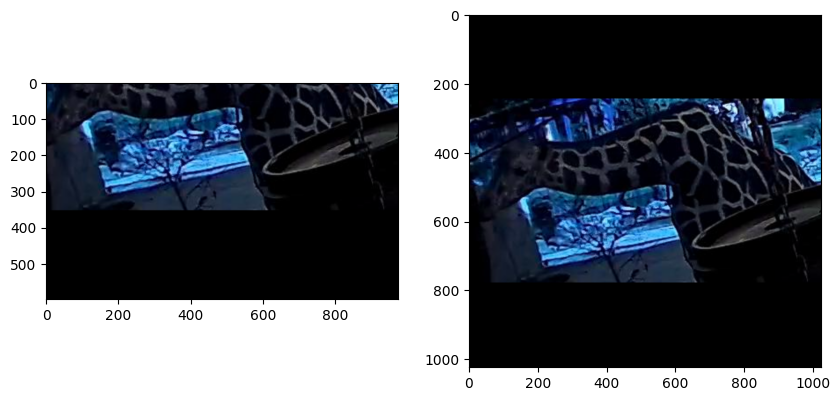

______________________________________________________
Score: 2845714.75 - ReId: 4|4 


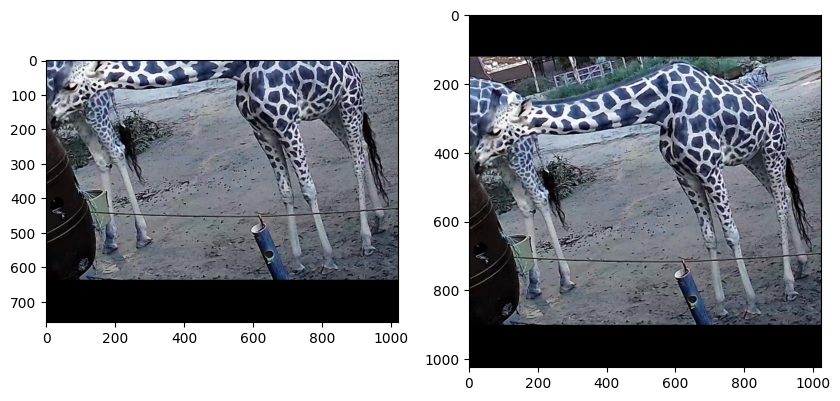

______________________________________________________
Score: 645401.625 - ReId: 1|2 


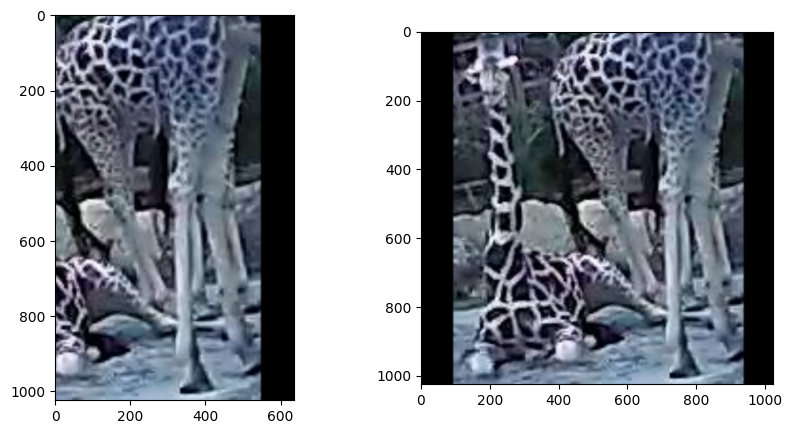

______________________________________________________
Score: 2072174.25 - ReId: 2|2 


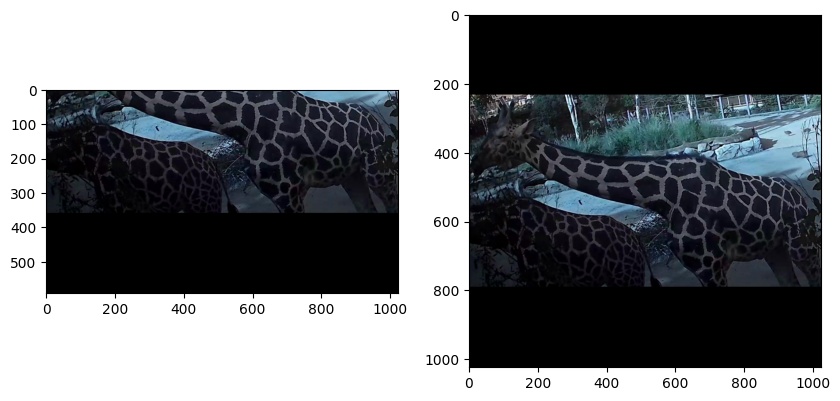

______________________________________________________
Score: 22273.4609375 - ReId: 4|3 


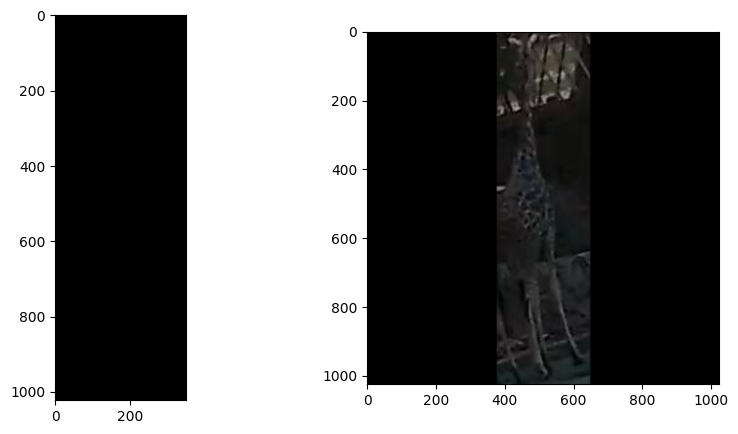

______________________________________________________
Score: 2192677.25 - ReId: 4|4 


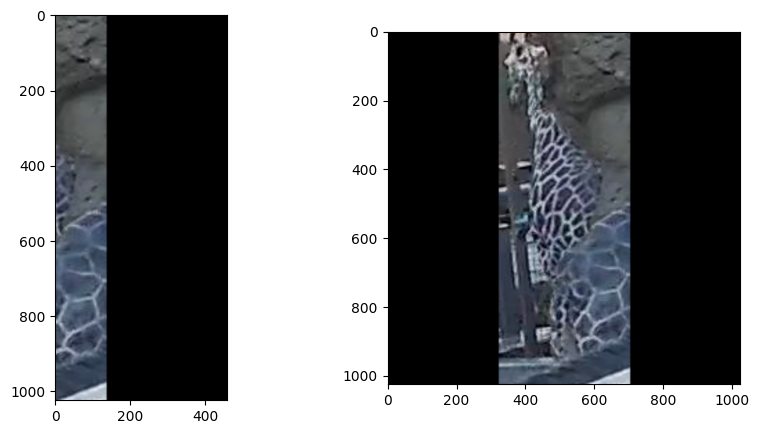

______________________________________________________
Score: 2849684.0 - ReId: 1|4 


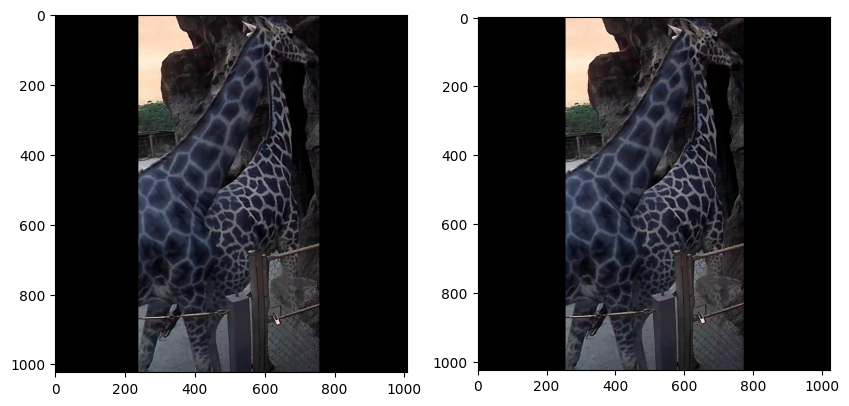

______________________________________________________
Score: 4208370.5 - ReId: 4|4 


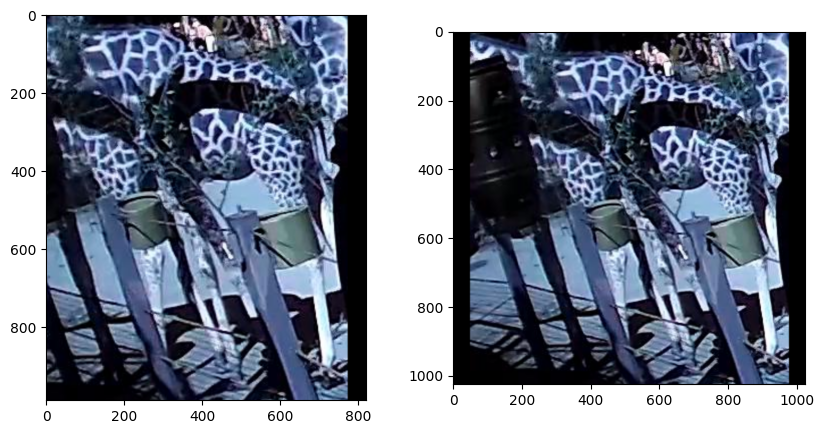

______________________________________________________
Score: 1748536.25 - ReId: 2|2 


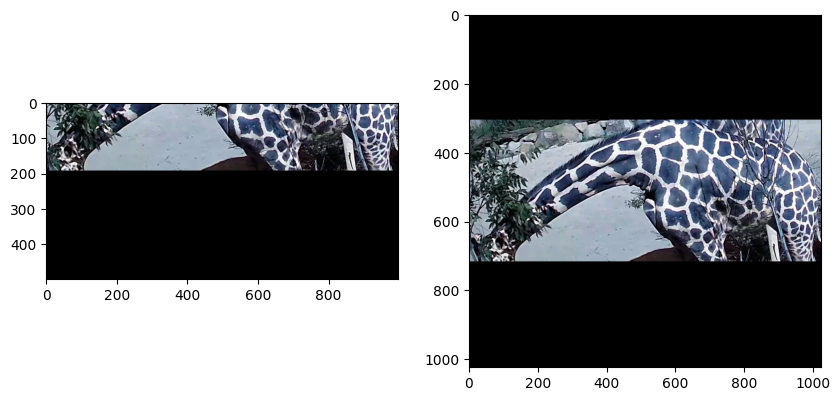

______________________________________________________
Score: 62706.05859375 - ReId: 3|3 


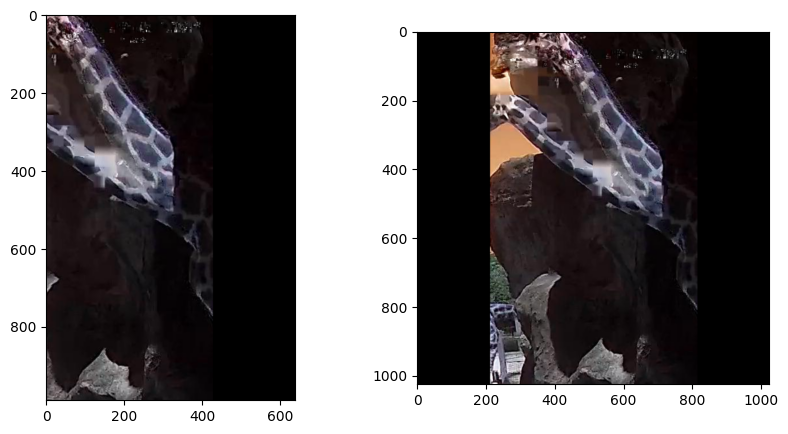

______________________________________________________
Score: 2847394.5 - ReId: 1|1 


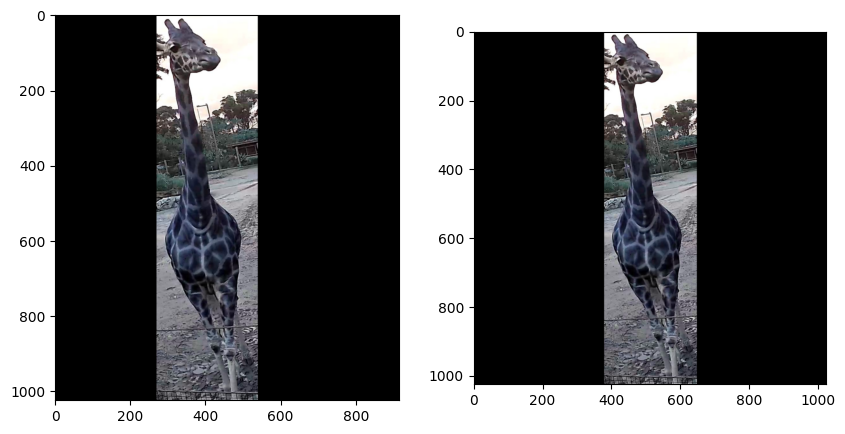

______________________________________________________
Score: 3244370.5 - ReId: 3|3 


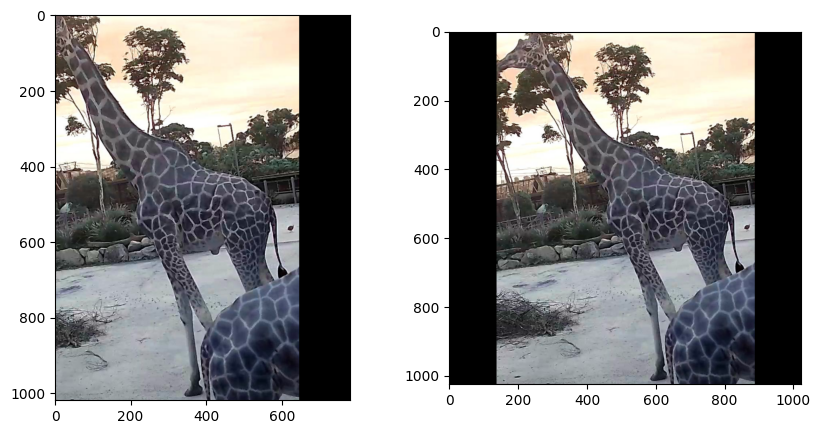

______________________________________________________
Score: 498916.6875 - ReId: 3|3 


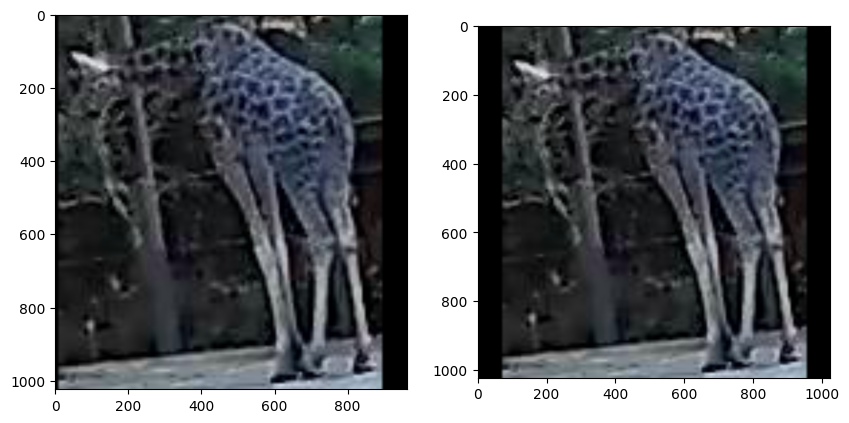

______________________________________________________
Score: 3221483.5 - ReId: 4|4 


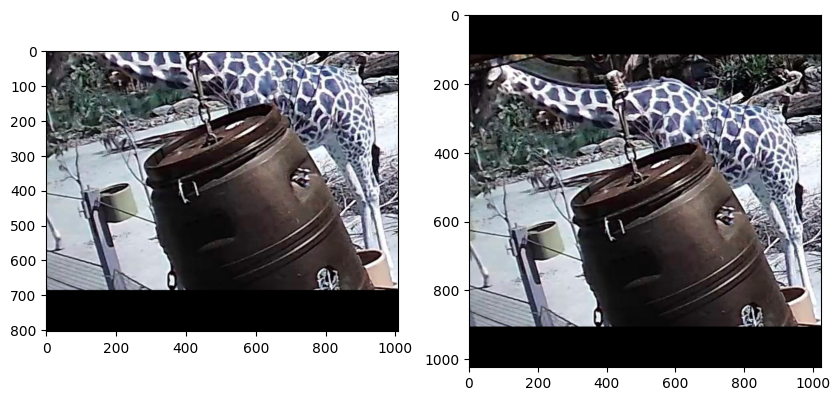

______________________________________________________
Score: 223015.375 - ReId: 1|1 


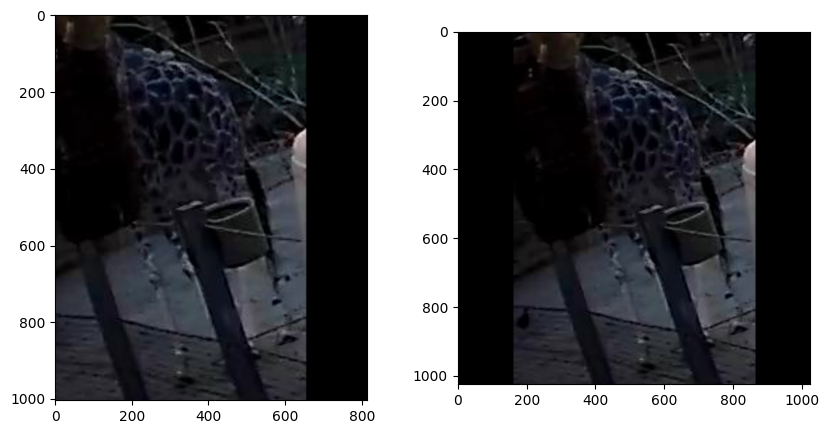

______________________________________________________
Score: 1921285.625 - ReId: 3|2 


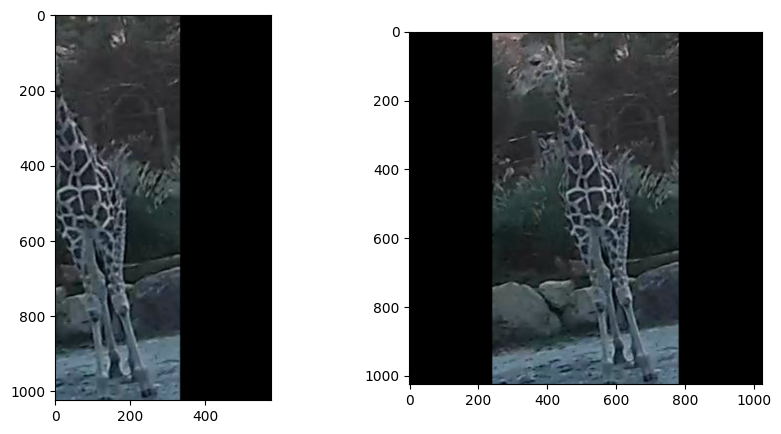

______________________________________________________
Score: 290661.96875 - ReId: 2|1 


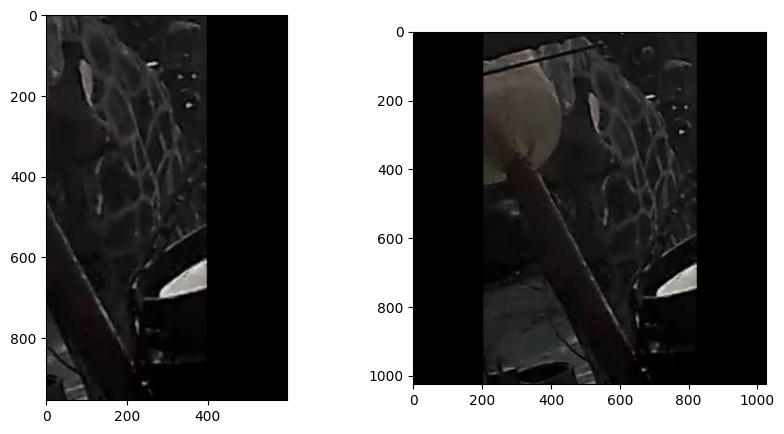

______________________________________________________


In [11]:
number_of_samples = 20
for sample in random.sample(raw_results, number_of_samples):
    dump_crop(sample[0], sample[1], sample[2], sample[3], sample[4])


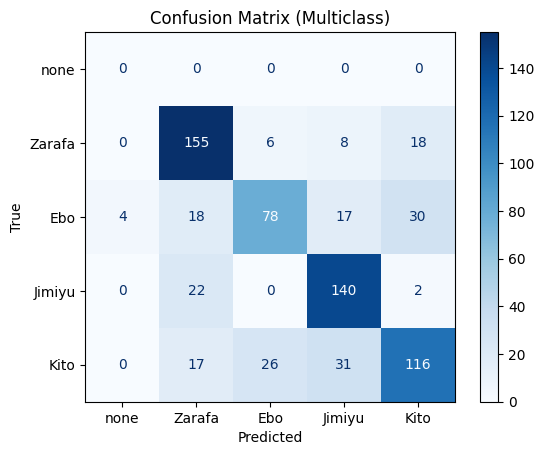

In [12]:
# Generate and display the confusion matrix
cm = confusion_matrix(known_classes, prediction_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["none", "Zarafa", "Ebo", "Jimiyu", "Kito"])
disp.plot(cmap=plt.cm.Blues)

disp.ax_.set_xlabel('Predicted')
disp.ax_.set_ylabel('True')
plt.title("Confusion Matrix (Multiclass)")
plt.show()


In [13]:
print(f"Images that had no reid embeddings {missed_count} ({(missed_count/num_images)*100:.2f}%)")


Images that had no reid embeddings 4 (0.58%)


In [14]:

def render_classification_report(data) -> pd.DataFrame:
    output: dict = {}
    classes: list = ["1","2","3","4","weighted avg"]
    class_names: list = ["Zarafa", "Ebo", "Jimiyu", "Kito", "Weighted average"]
    output["Name"] = class_names
    for key in data[classes[0]]:
        output[key.capitalize()] = [f"{data[cls][key]*100:.2f}%" if data[cls][key] < 1 else f"{data[cls][key]}" for cls in classes]
    df = pd.DataFrame(output)
    return df

cr = classification_report(known_classes, prediction_classes, output_dict=True)
df = render_classification_report(cr)
display(HTML(f"{df.to_html(index=False)}<b>Accuracy:</b> {cr["accuracy"] * 100:.2f}%"))

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Name,Precision,Recall,F1-score,Support
Zarafa,73.11%,82.89%,77.69%,187.0
Ebo,70.91%,53.06%,60.70%,147.0
Jimiyu,71.43%,85.37%,77.78%,164.0
Kito,69.88%,61.05%,65.17%,190.0
Weighted average,71.35%,71.08%,70.62%,688.0
